# Fixed-checkpoint finite-state grid evaluation

This notebook evaluates the already-trained finite-state ProsQA checkpoints. Each checkpoint has a fixed state dimension `d` and quantization precision `p`; the notebook does **not** generate a second grid, change quantization, or train a new bottleneck.

The model configuration is the 40-token GPT-2 architecture in `configs/symbol-2layer-8head-768dim.json`. Its vocabulary is the repository's built-in `STokenizer`; no tokenizer path is needed.

In [1]:
from __future__ import annotations

import gc
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import AutoConfig, AutoModelForCausalLM

from dataset import MyCollator, get_graph_latent_question_dataset
from finite_cot.rbs_adapter import StrictFiniteStateCoconut
from stokenizer import STokenizer
from utils import Config, set_seed

ROOT = Path.cwd().resolve()
if not (ROOT / 'configs' / 'symbol-2layer-8head-768dim.json').exists():
    raise RuntimeError('Run this notebook from the repository root.')
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('root:', ROOT)
print('device:', DEVICE)

/home/quanghung20gg/anaconda3/envs/evaluate/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.0.post2)/charset_normalizer (3.4.1) doesn't match a supported version!
  warnings.warn(


root: /home/quanghung20gg/Documents/new/LCoT
device: cuda:0


In [2]:
# Cell 2 — paths and the fixed (d, p) associated with each checkpoint.
# model_path must name the checkpoint file, not only its parent directory.
MODEL_SPECS = [
    {
        'name': 'd16-p4',
        'config_path': 'configs/symbol-2layer-8head-768dim.json',
        'model_path': 'ckpts/prosqa-finite-state-readonly-qat-b200-d16-mb4-bfloat16/checkpoint_214',
        'd': 16,
        'p': 4,
    },
    {
        'name': 'd16-p8',
        'config_path': 'configs/symbol-2layer-8head-768dim.json',
        'model_path': 'ckpts/prosqa-finite-state-readonly-qat-b200-d16-mb8-bfloat16/checkpoint_211',
        'd': 16,
        'p': 8,
    },
    {
        'name': 'd32-p4',
        'config_path': 'configs/symbol-2layer-8head-768dim.json',
        'model_path': 'ckpts/prosqa-finite-state-readonly-qat-b200-d32-mb4-bfloat16/checkpoint_189',
        'd': 32,
        'p': 4,
    },
    {
        'name': 'd32-p8',
        'config_path': 'configs/symbol-2layer-8head-768dim.json',
        'model_path': 'ckpts/prosqa-finite-state-readonly-qat-b200-d32-mb8-bfloat16/checkpoint_255',
        'd': 32,
        'p': 8,
    },
    {
        'name': 'd64-p4',
        'config_path': 'configs/symbol-2layer-8head-768dim.json',
        'model_path': 'ckpts/prosqa-finite-state-readonly-qat-b200-d64-mb4-bfloat16/checkpoint_209',
        'd': 64,
        'p': 4,
    },
    {
        'name': 'd64-p8',
        'config_path': 'configs/symbol-2layer-8head-768dim.json',
        'model_path': 'ckpts/prosqa-finite-state-readonly-qat-b200-d64-mb8-bfloat16/checkpoint_158',
        'd': 64,
        'p': 8,
    },
]

# Evaluation grid and testing controls. Each fixed (d,p) checkpoint is tested at every T.
T_VALUES = [1, 2, 4, 8]
TEST_ONLY_FIRST = False
MAX_EXAMPLES = None
EVAL_PATH = ROOT / 'data' / 'prosqa_test_graph_4_coconut.json'
ACCESS_MODE = 'readonly_input'
SEED = 17
OUTPUT_DIR = ROOT / 'results' / 'fixed_checkpoint_grid'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_SPECS = MODEL_SPECS[:1] if TEST_ONLY_FIRST else MODEL_SPECS
print(f'{len(RUN_SPECS)} checkpoints x {len(T_VALUES)} T values = {len(RUN_SPECS) * len(T_VALUES)} evaluations')
pd.DataFrame(MODEL_SPECS).assign(retained_bits=lambda x: x.d * x.p)

6 checkpoints x 4 T values = 24 evaluations


,name,config_path,model_path,d,p,retained_bits
0,d16-p4,configs/symbol-2layer-8head-768dim.json,ckpts/prosqa-finite-state-readonly-qat-b200-d1...,16,4,64
1,d16-p8,configs/symbol-2layer-8head-768dim.json,ckpts/prosqa-finite-state-readonly-qat-b200-d1...,16,8,128
2,d32-p4,configs/symbol-2layer-8head-768dim.json,ckpts/prosqa-finite-state-readonly-qat-b200-d3...,32,4,128
3,d32-p8,configs/symbol-2layer-8head-768dim.json,ckpts/prosqa-finite-state-readonly-qat-b200-d3...,32,8,256
4,d64-p4,configs/symbol-2layer-8head-768dim.json,ckpts/prosqa-finite-state-readonly-qat-b200-d6...,64,4,256
5,d64-p8,configs/symbol-2layer-8head-768dim.json,ckpts/prosqa-finite-state-readonly-qat-b200-d6...,64,8,512


## Validate the registry

The checks run before allocating a model. Duplicate `(d,p)` entries and missing files fail immediately.

In [3]:
def validate_registry(specs):
    required = {'name', 'config_path', 'model_path', 'd', 'p'}
    seen = set()
    for spec in specs:
        missing = required - set(spec)
        if missing:
            raise ValueError(f"{spec.get('name', '<unnamed>')} is missing {sorted(missing)}")
        key = (int(spec['d']), int(spec['p']))
        if key in seen:
            raise ValueError(f'duplicate grid cell {key}')
        seen.add(key)
        for field in ('config_path', 'model_path'):
            path = ROOT / spec[field]
            if not path.is_file():
                raise FileNotFoundError(f"{spec['name']} {field}: {path}")
        if int(spec['d']) <= 0 or int(spec['p']) <= 0:
            raise ValueError(f"invalid d/p for {spec['name']}")

validate_registry(MODEL_SPECS)
print(f'{len(MODEL_SPECS)} grid cells configured; {len(RUN_SPECS)} selected for this run.')

6 grid cells configured; 6 selected for this run.


## Exact checkpoint loader

The checkpoint is loaded into the same `StrictFiniteStateCoconut` topology used during training. `strict=True` makes an incorrect `d`, architecture, or checkpoint fail instead of silently evaluating a partially initialized model.

In [4]:
def load_fixed_checkpoint(spec):
    tokenizer = STokenizer()
    config = AutoConfig.from_pretrained(ROOT / spec['config_path'])
    if config.model_type != 'gpt2' or int(config.vocab_size) != len(tokenizer):
        raise ValueError(
            f"Expected the old 40-token GPT-2 model; got type={config.model_type}, "
            f"vocab={config.vocab_size}, tokenizer={len(tokenizer)}"
        )
    base = AutoModelForCausalLM.from_config(config)
    model = StrictFiniteStateCoconut(
        base,
        tokenizer.convert_tokens_to_ids('<|latent|>'),
        tokenizer.convert_tokens_to_ids('<|start-latent|>'),
        tokenizer.convert_tokens_to_ids('<|end-latent|>'),
        tokenizer.eos_token_id,
        {
            'enabled': True,
            'state_dim': int(spec['d']),
            'model_bits': int(spec['p']),
            'bits_per_coordinate': int(spec['p']),
            'clip_value': 1.0,
            'learnable_clip': False,
            'access_mode': ACCESS_MODE,
        },
    )
    state = torch.load(ROOT / spec['model_path'], map_location='cpu', weights_only=True)
    if isinstance(state, dict) and 'state_dict' in state:
        state = state['state_dict']
    model.load_state_dict(state, strict=True)
    model.to(DEVICE).eval()
    return model, tokenizer

## Evaluation data and hidden-step sweep

The prompt is rendered deterministically once per example, then exactly `T` latent tokens are inserted. This makes comparisons across `T in {1,2,4,8}` use the same graph, edge order, candidate order, and target. `MAX_EXAMPLES` only truncates the testing run.


In [5]:
raw_eval = json.loads(EVAL_PATH.read_text())
answers = [str(item['target']) for item in raw_eval]

def make_eval_loader(tokenizer, hidden_steps):
    rng = random.Random(SEED)
    dataset = []
    limit = len(raw_eval) if MAX_EXAMPLES is None else min(int(MAX_EXAMPLES), len(raw_eval))
    latent_id = tokenizer.convert_tokens_to_ids('<|latent|>')
    for index, sample in enumerate(raw_eval[:limit]):
        edges = list(sample['edges'])
        rng.shuffle(edges)
        candidates = [sample['target'], sample['neg_target']]
        rng.shuffle(candidates)
        question = (
            '<eos> '
            + '|'.join(f' {edge[0]} {edge[1]} ' for edge in edges).strip()
            + f" [Q] {candidates[0]} {candidates[1]} [R] {sample['root']}"
            + ' <|latent|>' * int(hidden_steps)
            + ' [A] '
        )
        ids = tokenizer.encode(question, add_special_tokens=False)
        if ids.count(latent_id) != int(hidden_steps):
            raise AssertionError('incorrect hidden-step token count')
        dataset.append({
            'input_ids': ids,
            'attention_mask': [1] * len(ids),
            'position_ids': list(range(len(ids))),
            'idx': index,
        })
    collator = MyCollator(tokenizer, latent_id=latent_id, label_pad_token_id=-100)
    return DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=collator)

print('evaluation examples available:', len(raw_eval))
print('hidden-step grid:', T_VALUES)

evaluation examples available: 419
hidden-step grid: [1, 2, 4, 8]


In [6]:
@torch.inference_mode()
def evaluate_checkpoint(spec, hidden_steps):
    set_seed(SEED)
    model, tokenizer = load_fixed_checkpoint(spec)
    loader = make_eval_loader(tokenizer, hidden_steps)
    rows = []
    saturation = []
    started = time.time()

    for batch in tqdm(loader, desc=f"{spec['name']} T={hidden_steps}"):
        sample_index = int(batch['idx'][0])
        inputs = {
            key: value.to(DEVICE)
            for key, value in batch.items()
            if value is not None and key not in {'idx', 'position_ids'}
        }
        generated = model.generate(**inputs, max_new_tokens=1)
        decoded = tokenizer.decode(generated[0], skip_special_tokens=True).replace('<eos>', '').strip()
        prediction = decoded.split('[A]')[-1].replace(',', '').strip()
        target = answers[sample_index]

        codes = model.export_state_codes()[0]
        flat_codes = np.asarray(codes, dtype=np.int64).reshape(-1)
        if flat_codes.size:
            maximum = (1 << int(spec['p'])) - 1
            saturation.append(float(np.mean((flat_codes == 0) | (flat_codes == maximum))))

        ledger = model.last_ledger.to_dict() if model.last_ledger is not None else {}
        rows.append({
            'model': spec['name'], 'd': int(spec['d']), 'p': int(spec['p']), 'T': int(hidden_steps),
            'retained_bits': int(spec['d']) * int(spec['p']),
            'example_index': sample_index, 'target': target, 'prediction': prediction,
            'correct': int(prediction == target), 'state_trace': codes,
            'recurrent_updates': ledger.get('recurrent_updates'),
            'backbone_forwards': int(model.gen_forward_cnt),
        })

    frame = pd.DataFrame(rows)
    summary = {
        'model': spec['name'], 'config_path': spec['config_path'], 'model_path': spec['model_path'],
        'd': int(spec['d']), 'p': int(spec['p']), 'T': int(hidden_steps), 'retained_bits': int(spec['d']) * int(spec['p']),
        'examples': len(frame), 'accuracy': float(frame.correct.mean()),
        'saturation_rate': float(np.mean(saturation)) if saturation else None,
        'mean_backbone_forwards': float(frame.backbone_forwards.mean()),
        'elapsed_seconds': time.time() - started,
    }
    del model
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return summary, frame

## Run the selected checkpoint × T grid

With `TEST_ONLY_FIRST=False`, all six checkpoints run freshly at all four hidden-step budgets, producing 24 evaluations. Predictions are kept only in memory during evaluation; no per-example JSONL files are written and previous results are never reused.


In [ ]:
summaries = []
for spec in RUN_SPECS:
    for hidden_steps in T_VALUES:
        summary, _ = evaluate_checkpoint(spec, hidden_steps)
        summaries.append(summary)

results = pd.DataFrame(summaries).sort_values(['d', 'p', 'T'])
results.to_csv(OUTPUT_DIR / 'grid_results.csv', index=False)
display(results)

## Three separate grid views

Each chart is rendered as a separate figure. Accuracy is on the y-axis; the x-axis is respectively `T`, `d`, and `p`, with every combination of the remaining coordinates drawn as a separate line.


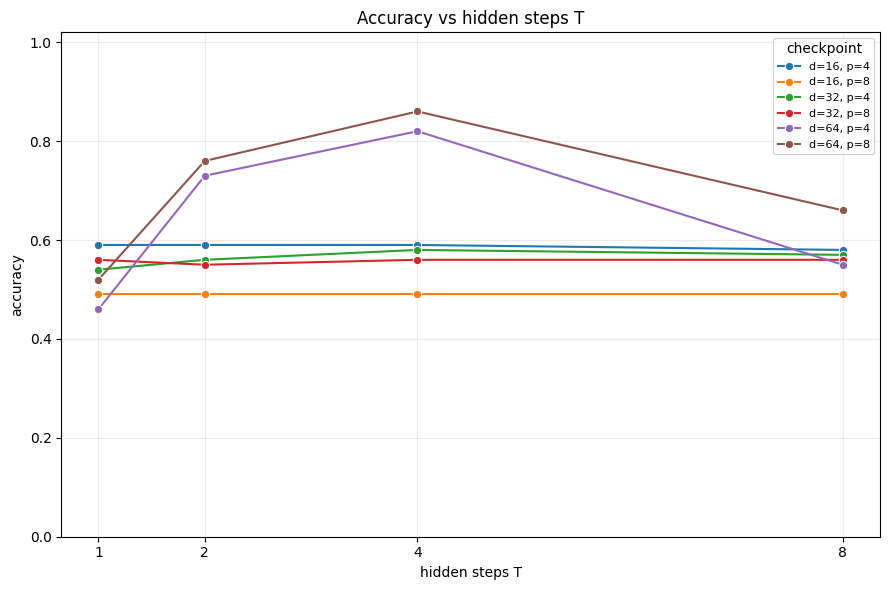

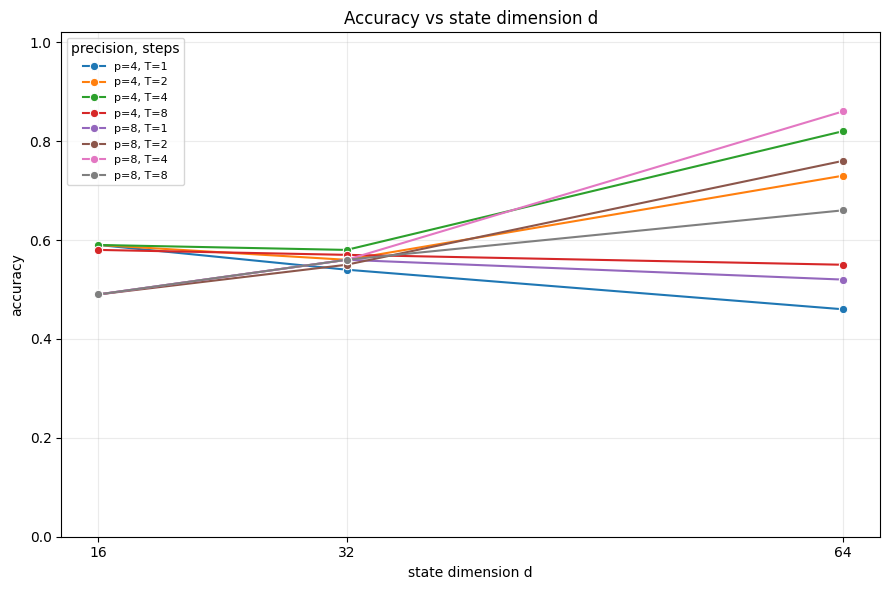

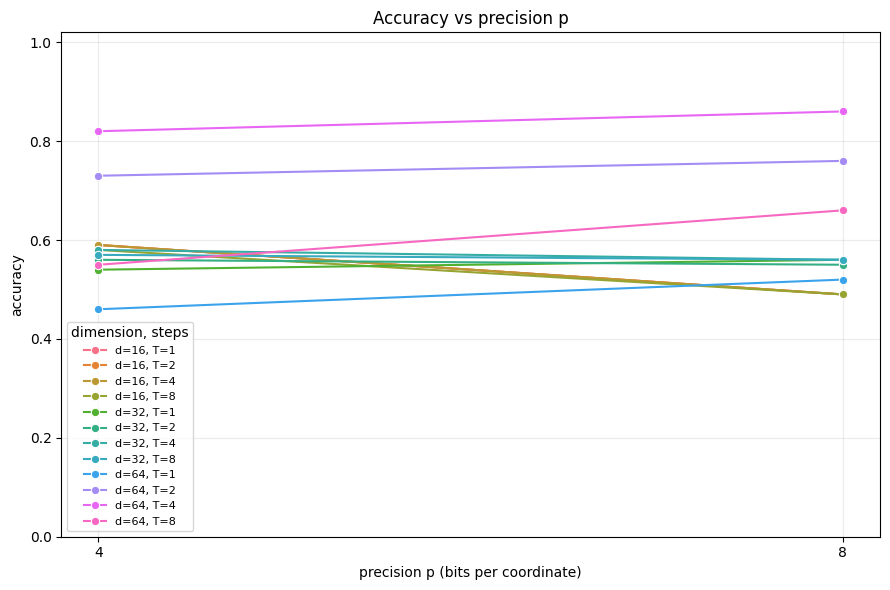

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

if results.empty:
    print('No completed results.')
else:
    plot_data = results.copy()
    plot_data['d,p'] = plot_data.apply(
        lambda row: f"d={int(row['d'])}, p={int(row['p'])}", axis=1
    )
    plot_data['p,T'] = plot_data.apply(
        lambda row: f"p={int(row['p'])}, T={int(row['T'])}", axis=1
    )
    plot_data['d,T'] = plot_data.apply(
        lambda row: f"d={int(row['d'])}, T={int(row['T'])}", axis=1
    )

    # Figure 1: x = T; one line for each (d, p).
    fig_t, ax_t = plt.subplots(figsize=(9, 6))
    sns.lineplot(
        data=plot_data, x='T', y='accuracy', hue='d,p',
        marker='o', errorbar=None, ax=ax_t
    )
    ax_t.set_title('Accuracy vs hidden steps T')
    ax_t.set_xlabel('hidden steps T')
    ax_t.set_ylabel('accuracy')
    ax_t.set_xticks(T_VALUES)
    ax_t.set_ylim(0, 1.02)
    ax_t.grid(alpha=.25)
    ax_t.legend(title='checkpoint', fontsize=8)
    fig_t.tight_layout()
    fig_t.savefig(OUTPUT_DIR / 'accuracy_vs_T.pdf', bbox_inches='tight')
    fig_t.savefig(OUTPUT_DIR / 'accuracy_vs_T.png', dpi=200, bbox_inches='tight')
    plt.show()

    # Figure 2: x = d; one line for each (p, T).
    fig_d, ax_d = plt.subplots(figsize=(9, 6))
    sns.lineplot(
        data=plot_data, x='d', y='accuracy', hue='p,T',
        marker='o', errorbar=None, ax=ax_d
    )
    ax_d.set_title('Accuracy vs state dimension d')
    ax_d.set_xlabel('state dimension d')
    ax_d.set_ylabel('accuracy')
    ax_d.set_xticks(sorted(plot_data['d'].unique()))
    ax_d.set_ylim(0, 1.02)
    ax_d.grid(alpha=.25)
    ax_d.legend(title='precision, steps', fontsize=8)
    fig_d.tight_layout()
    fig_d.savefig(OUTPUT_DIR / 'accuracy_vs_d.pdf', bbox_inches='tight')
    fig_d.savefig(OUTPUT_DIR / 'accuracy_vs_d.png', dpi=200, bbox_inches='tight')
    plt.show()

    # Figure 3: x = p; one line for each (d, T).
    fig_p, ax_p = plt.subplots(figsize=(9, 6))
    sns.lineplot(
        data=plot_data, x='p', y='accuracy', hue='d,T',
        marker='o', errorbar=None, ax=ax_p
    )
    ax_p.set_title('Accuracy vs precision p')
    ax_p.set_xlabel('precision p (bits per coordinate)')
    ax_p.set_ylabel('accuracy')
    ax_p.set_xticks(sorted(plot_data['p'].unique()))
    ax_p.set_ylim(0, 1.02)
    ax_p.grid(alpha=.25)
    ax_p.legend(title='dimension, steps', fontsize=8)
    fig_p.tight_layout()
    fig_p.savefig(OUTPUT_DIR / 'accuracy_vs_p.pdf', bbox_inches='tight')
    fig_p.savefig(OUTPUT_DIR / 'accuracy_vs_p.png', dpi=200, bbox_inches='tight')
    plt.show()


## Section 4.5 — FrontierRate validation contract

The following validator is deliberately separate from the ProsQA checkpoint grid above. The theorem-facing outcomes are valid only for FrontierRate prefix/query records. Passing the ProsQA `results` table will fail because it has no random frontier, continuation index, hard channel key, or queried-bit probability.

Required `frontier_query_rows` columns:

- configuration: `model, seed, split, n, d, p, L, T`;
- query: `prefix_id, query, label, prediction, prob_1`;
- audits: string/bytes `state_key, transcript_key, bit_hash`, plus `saturation_rate`.

For all-continuation metrics, provide every `query=0,...,n-1` for each audited prefix. For reconstruction, provide one row per prefix with `channel_codes` and the complete `bits` vector. For causal patching, provide recipient and donor labels plus predictions before and after each state/transcript patch.
